# Privacy Archetypes

Analysis for multi-metric clustering and PCA visualization of privacy archetypes.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

metrics_results = Path("../data/mhealth_apps_metrics.csv")
if not metrics_results.exists():
    raise FileNotFoundError(
        "Could not find `mhealth_apps_metrics.csv` in the notebook folder or at ../data/."
    )

REGION_MAP = {
    "us": "North America", "ca": "North America", "gl":"North America",
    "mx": "Latin America", "br": "Latin America", "ar": "Latin America", 
    "cl": "Latin America",
    "de": "Europe", "fr": "Europe", "gb": "Europe", 
    "pl": "Europe",
    "tr": "Middle East", "il": "Middle East", "sa": "Middle East", 
    "ae": "Middle East",
    "in": "Asia", "jp": "Asia", "sg": "Asia", 
    "kr": "Asia",
    "za": "Africa", "mz": "Africa", "ng": "Africa", 
    "ke": "Africa",
    "au": "Oceania", "nz": "Oceania", 
    "pg": "Oceania"
}

COUNTRY_LABEL_MAP = {
    "us": "United States", "ca": "Canada", "gl":"Greenland",
    "mx": "Mexico", "br": "Brazil", "ar": "Argentina",
    "cl": "Chile",
    "de": "Germany", "fr": "France", "gb": "Great Britain",
    "pl": "Poland",
    "tr": "Turkey", "il": "Israel", "sa": "Saudi Arabia",
    "ae": "United Arab Emirates",
    "in": "India", "jp": "Japan", "sg": "Singapore",
    "kr": "South Korea",
    "za": "South Africa", "mz": "Mozambique", "ng": "Nigeria",
    "ke": "Kenya",
    "au": "Australia", "nz": "New Zealand",
    "pg": "Papua New Guinea"
}

REGION_ORDER = [
    "North America", "Latin America", "Europe",
    "Middle East", "Asia", "Africa", "Oceania"
]

region_palette = plt.cm.tab10(np.linspace(0, 1, len(REGION_ORDER)))
REGION_COLORS = {region: region_palette[i] for i, region in enumerate(REGION_ORDER)}
category_palette = plt.cm.tab20(np.linspace(0, 1, 20))


In [8]:
import pandas as pd

df = pd.read_csv(metrics_results, low_memory=False)
print("Raw shape:", df.shape)

required_metrics = ["ADII", "DGI", "PCLR", "AS"]
missing_required = [c for c in required_metrics if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required metric columns: {missing_required}")

analysis_df = df.copy()

print("Analysis shape:", analysis_df.shape)
print("Unique apps:", analysis_df["app_id"].nunique())

display_cols = [
    "app_id", "country", "country_label", "region", "category",
    "ADII", "DGI", "PCLR", "AS",
    "observed_count", "disclosed_count", "missing_count", "misleading_count"
]
display_cols = [c for c in display_cols if c in analysis_df.columns]

Raw shape: (23392, 134)
Analysis shape: (23392, 134)
Unique apps: 931


In [9]:

summary = pd.DataFrame({
    "non_null": analysis_df[["ADII", "DGI", "PCLR", "AS"]].notna().sum(),
    "mean": analysis_df[["ADII", "DGI", "PCLR", "AS"]].mean(),
    "median": analysis_df[["ADII", "DGI", "PCLR", "AS"]].median(),
    "std": analysis_df[["ADII", "DGI", "PCLR", "AS"]].std(),
    "min": analysis_df[["ADII", "DGI", "PCLR", "AS"]].min(),
    "max": analysis_df[["ADII", "DGI", "PCLR", "AS"]].max(),
}).round(4)
summary


,non_null,mean,median,std,min,max
ADII,23392,189.0859,100.0000,323.8028,7.0000,12935.0000
DGI,23392,0.2559,0.0000,0.3968,0.0000,1.0000
PCLR,11967,0.3063,0.2000,0.3386,0.0000,1.0000
AS,23383,0.3787,0.3761,0.0924,0.1064,0.7473


In [10]:

country_level = analysis_df.copy()

metric_agg = {
    "ADII": "mean",
    "DGI": "mean",
    "PCLR": "mean",
    "AS": "mean",
}

meta_agg = {
    "country_label": "nunique",
    "region": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
    "category": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
    "num_permissions": "mean",
    "num_dangerous_permissions": "mean",
    "num_trackers": "mean",
    "downloads_int": "mean",
    "average_score": "mean",
}

agg_dict = {}
for k, v in {**metric_agg, **meta_agg}.items():
    if k in analysis_df.columns:
        agg_dict[k] = v

app_level = analysis_df.groupby("app_id", as_index=False).agg(agg_dict)
app_level = app_level.rename(columns={"country_label": "country_count"})
app_level_all = app_level.copy()

if "PCLR" not in app_level_all.columns:
    if "app_country_PCLR" in analysis_df.columns:
        pclr_fallback = (
            analysis_df.groupby("app_id", as_index=False)["app_country_PCLR"]
            .mean()
            .rename(columns={"app_country_PCLR": "PCLR"})
        )
        app_level_all = app_level_all.merge(pclr_fallback, on="app_id", how="left")
    elif {"app_country_pre_sensitive_instances", "app_country_total_sensitive_instances"}.issubset(analysis_df.columns):
        pclr_fallback = (
            analysis_df.groupby("app_id", as_index=False)[
                ["app_country_pre_sensitive_instances", "app_country_total_sensitive_instances"]
            ]
            .mean()
        )
        denom = pclr_fallback["app_country_total_sensitive_instances"].replace(0, np.nan)
        pclr_fallback["PCLR"] = pclr_fallback["app_country_pre_sensitive_instances"] / denom
        app_level_all = app_level_all.merge(pclr_fallback[["app_id", "PCLR"]], on="app_id", how="left")

print("Country-level rows:", len(country_level))
print("App-level rows:", len(app_level_all))
print("App-level metric columns:", [c for c in ["ADII", "DGI", "PCLR", "AS"] if c in app_level_all.columns])
app_level = app_level_all.copy()



Country-level rows: 23392
App-level rows: 931
App-level metric columns: ['ADII', 'DGI', 'PCLR', 'AS']



## Privacy archetypes from multi-metric clustering

This section clusters apps using `ADII`, `DGI`, `PCLR`, and `AS`, then labels each cluster by its dominant privacy pattern.


In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cluster_source = (
    app_level_all.copy()
    if "app_level_all" in globals()
    else app_level.copy()
    if "app_level" in globals()
    else analysis_df.copy()
)

metric_aliases = {
    "ADII": ["ADII", "ADII_mean", "ADII_median"],
    "DGI": ["DGI", "DGI_mean", "DGI_median"],
    "PCLR": ["PCLR", "PCLR_mean", "PCLR_median"],
    "AS": ["AS", "AS_mean", "AS_median"],
    "app_id": ["app_id"],
    "category": ["category"],
    "num_trackers": ["num_trackers"],
    "num_permissions": ["num_permissions"],
    "downloads_int": ["downloads_int", "downloads"],
}

cluster_df = pd.DataFrame(index=cluster_source.index)

for target, candidates in metric_aliases.items():
    for cand in candidates:
        if cand in cluster_source.columns:
            cluster_df[target] = cluster_source[cand]
            break

feature_cols = ["ADII", "DGI", "PCLR", "AS"]
needed = ["app_id"] + feature_cols

missing = [c for c in needed if c not in cluster_df.columns]
if missing:
    raise ValueError(
        f"Clustering requires {needed}. "
        f"Missing: {missing}. "
        f"Available columns: {cluster_source.columns.tolist()}"
    )


for c in feature_cols + ["num_trackers", "num_permissions", "downloads_int"]:
    if c in cluster_df.columns:
        cluster_df[c] = pd.to_numeric(cluster_df[c], errors="coerce")

n_before_dropna = len(cluster_df)
cluster_df = cluster_df.dropna(subset=feature_cols).copy()
n_excluded = n_before_dropna - len(cluster_df)
print(
    f"Apps with complete {feature_cols} metrics: {len(cluster_df)}/{n_before_dropna} "
    f"({n_excluded} excluded, typically apps observed in too few countries for AS to be defined)."
)

if cluster_df["app_id"].duplicated().any():
    agg = {
        "ADII": "mean",
        "DGI": "mean",
        "PCLR": "mean",
        "AS": "mean",
    }

    for extra in ["category", "num_trackers", "num_permissions", "downloads_int"]:
        if extra in cluster_df.columns:
            if pd.api.types.is_numeric_dtype(cluster_df[extra]):
                agg[extra] = "mean"
            else:
                agg[extra] = "first"

    cluster_df = cluster_df.groupby("app_id", as_index=False).agg(agg)

if len(cluster_df) < 3:
    raise ValueError("Need at least 3 apps with complete metrics for clustering.")

cluster_df["log_ADII"] = np.log1p(cluster_df["ADII"])
cluster_feature_cols = ["log_ADII", "DGI", "PCLR", "AS"]

X = cluster_df[cluster_feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 3

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=20,
)

cluster_df["archetype_id"] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, cluster_df["archetype_id"])
print(f"\nSilhouette score for k={n_clusters}: {sil_score:.3f}")

max_k_to_check = min(8, len(cluster_df) - 1)
if max_k_to_check >= 2:
    print("Silhouette score by k (for reference):")
    for k in range(2, max_k_to_check + 1):
        if k == n_clusters:
            continue
        trial_labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X_scaled)
        print(f"  k={k}: {silhouette_score(X_scaled, trial_labels):.3f}")


cluster_profile = (
    cluster_df.groupby("archetype_id")[feature_cols]
    .mean()
    .round(4)
)

cluster_profile_z = pd.DataFrame(
    scaler.transform(cluster_df.groupby("archetype_id")[cluster_feature_cols].mean()),
    index=cluster_profile.index,
    columns=[f"{c}_z" for c in cluster_feature_cols],
)

name_map = {}

high_collection_cid = cluster_profile["ADII"].idxmax()
name_map[high_collection_cid] = "High-collection, consent-weak"

remaining = cluster_profile.drop(high_collection_cid)
name_map[remaining["DGI"].idxmax()] = "Opaque, low-collection"
name_map[remaining["DGI"].idxmin()] = "Transparent"

cluster_df["privacy_archetype"] = cluster_df["archetype_id"].map(name_map)
cluster_profile["privacy_archetype"] = cluster_profile.index.map(name_map)

display(cluster_profile.reset_index())

print("\nArchetype counts:")
print(cluster_df["privacy_archetype"].value_counts())


Apps with complete ['ADII', 'DGI', 'PCLR', 'AS'] metrics: 920/931 (11 excluded, typically apps observed in too few countries for AS to be defined).

Silhouette score for k=3: 0.388
Silhouette score by k (for reference):
  k=2: 0.327
  k=4: 0.345
  k=5: 0.343
  k=6: 0.314
  k=7: 0.306
  k=8: 0.279


,archetype_id,ADII,DGI,PCLR,AS,privacy_archetype
0,0,183.3034,0.0299,0.2194,0.3829,Transparent
1,1,121.9130,0.8891,0.2424,0.3964,"Opaque, low-collection"
2,2,434.4662,0.2644,0.7726,0.2918,"High-collection, consent-weak"



Archetype counts:
privacy_archetype
Transparent                      625
Opaque, low-collection           220
High-collection, consent-weak     75
Name: count, dtype: int64


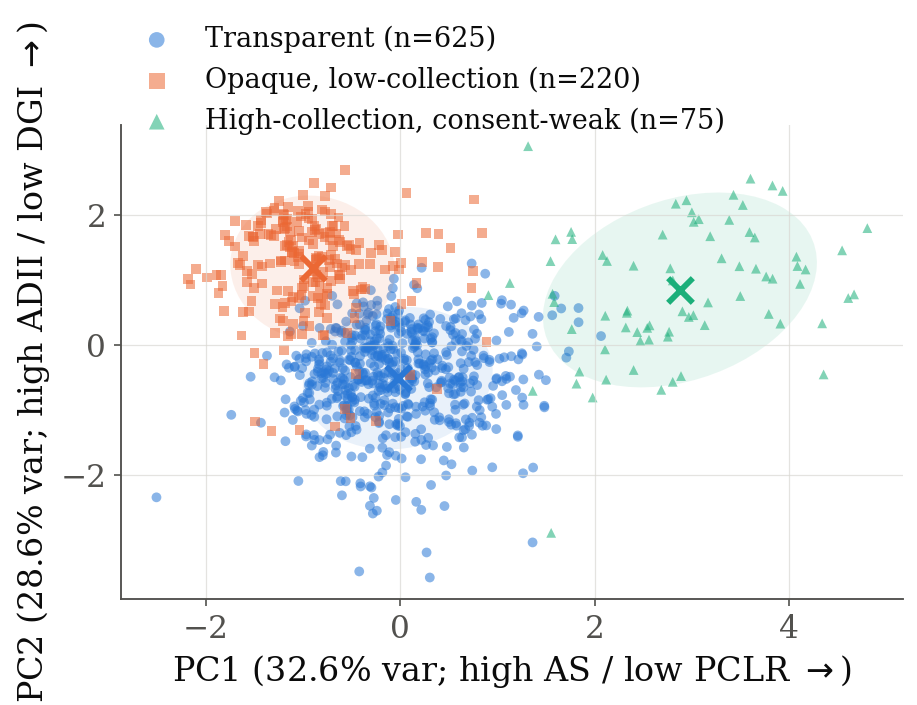

In [12]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plot_df = cluster_df.copy()
plot_df["PC1"] = coords[:, 0]
plot_df["PC2"] = coords[:, 1]

CATV = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID_COLOR = "#d9d8d3"

plt.rcParams.update({
    "font.size": 16,
    "font.family": "serif",
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.edgecolor": TEXT_SECONDARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
    "pdf.fonttype": 42,
    "figure.dpi": 150,
})

archetype_order = ["Transparent", "Opaque, low-collection", "High-collection, consent-weak"]
markers = ["o", "s", "^"]

fig, ax = plt.subplots(figsize=(6.4, 5.2))

for i, arch in enumerate(archetype_order):
    sub = plot_df[plot_df["privacy_archetype"] == arch]
    if sub.empty:
        continue
    color = CATV[i]

    ax.scatter(
        sub["PC1"], sub["PC2"],
        s=22, alpha=0.55, color=color, marker=markers[i],
        label=f"{arch} (n={len(sub)})", edgecolors="none",
    )

    cx, cy = sub["PC1"].mean(), sub["PC2"].mean()
    ax.scatter([cx], [cy], marker="x", s=140, color=color, linewidths=2.8, zorder=5)

    cov = np.cov(sub["PC1"], sub["PC2"])
    eigval, eigvec = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigvec[1, -1], eigvec[0, -1]))
    width, height = 2 * 1.5 * np.sqrt(eigval[-1]), 2 * 1.5 * np.sqrt(eigval[0])
    ell = Ellipse((cx, cy), width, height, angle=angle, facecolor=color, alpha=0.10, edgecolor="none")
    ax.add_patch(ell)

var = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC1 ({var[0]:.1f}% var; high AS / low PCLR $\\rightarrow$)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% var; high ADII / low DGI $\\rightarrow$)")
ax.legend(loc="upper left", frameon=False, fontsize=13, markerscale=1.6, bbox_to_anchor=(-0.02, 1.26), ncol=1)

fig.tight_layout()
fig.savefig("../figures/privacy_archetypes_pca.pdf", format="pdf", bbox_inches="tight")
plt.show()